# Emission Spectrum Basics

Transmission tells us about the atmosphere at the limb; emission tells us about the temperature structure at the dayside. This notebook builds an `EmissionModel` using the same component-oriented workflow as [Transmission spectrum basics](https://escience-taurex.github.io/taurex3/examples/03_transmission_basics.html), but the physics is fundamentally different: the spectrum is now the planet's own thermal emission, and its shape is governed by the vertical temperature gradient of the atmosphere. [Inspecting profiles](https://escience-taurex.github.io/taurex3/examples/06_inspecting_profiles.html) takes that dependence further by visualising non-isothermal profiles directly.

Emission spectroscopy measures the planet-to-star flux ratio $(F_p/F_s)$ as a function of wavelength. Unlike transmission, emission is sensitive to the vertical temperature structure: a temperature inversion, for instance, turns an absorption feature into an emission peak.

This example starts with a simple isothermal atmosphere and molecular absorption only — no CIA or Rayleigh scattering — to keep the baseline as clean as possible. More information about forward models is [here](../user/taurex/models.rst), temperature profiles are [here](../user/taurex/temperature.rst), planet parameters are [here](../user/taurex/planet.rst), and star parameters are [here](../user/taurex/star.rst).

## Data Note

This notebook uses the opacity files set up in [Setup and opacity data](https://escience-taurex.github.io/taurex3/examples/01_setup_and_data.html). TauREx provides the software to work with these datasets; the files themselves are third-party products from [ExoMol](https://www.exomol.com).

In [1]:
from _shared import build_emission_model

context = build_emission_model(include_cia=False, include_rayleigh=False, download=False)
em = context['em']

print('Emission model contributions:', [c.name for c in em.contribution_list])

Emission model contributions: ['Absorption']


## Running the Emission Model

Calling `model()` on an `EmissionModel` returns the same tuple as in the transmission case: wavenumber grid, planet-to-star flux ratio $F_p/F_s$, optical depth, and extras. With a single gas and an isothermal profile the result is close to a diluted blackbody with shallow absorption features.

In [2]:
wngrid, fpfs, tau, _ = em.model()
wlgrid = 10000 / wngrid[::-1]
fpfs = fpfs[::-1]

print(f'Computed {len(wngrid)} spectral points.')
print(f'Temperature profile spans {em.temperatureProfile.min():.1f} K to {em.temperatureProfile.max():.1f} K')

Computed 76744 spectral points.
Temperature profile spans 2000.0 K to 2000.0 K


In [3]:
print(f'Planet/star flux-ratio range: {fpfs.min():.6e} to {fpfs.max():.6e}')
print(f'Wavelength range: {wlgrid.min():.3f} to {wlgrid.max():.3f} um')

Planet/star flux-ratio range: 1.462632e-09 to 4.652038e-03
Wavelength range: 0.300 to 50.002 um


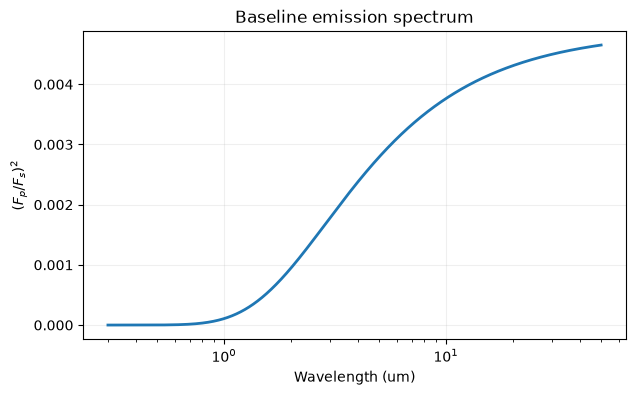

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(wlgrid, fpfs, lw=2)
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('$(F_p/F_s)^2$')
plt.title('Baseline emission spectrum')
plt.grid(alpha=0.2)

## Temperature Profile

Emission spectra are directly sensitive to atmospheric temperature structure, and plotting the T–P profile alongside the spectrum makes that connection tangible. An isothermal profile has no vertical contrast, so molecular features emerge only faintly against a near-blackbody continuum.

[Inspecting profiles](https://escience-taurex.github.io/taurex3/examples/06_inspecting_profiles.html) uses a `Guillot2010` profile to show what structured temperature looks like and how it changes the spectrum. More information about temperature profile types is [here](../user/taurex/temperature.rst).

### Composite emission regions

The same multimodel interface is available for emission and direct-imaging calculations through `model_type = multi_eclipse` and `model_type = multi_directimage`. These composite models combine several 1D regions using the same `parfiles` and `fractions` pattern used for transmission, which is useful for day-night or patchy-emission setups.

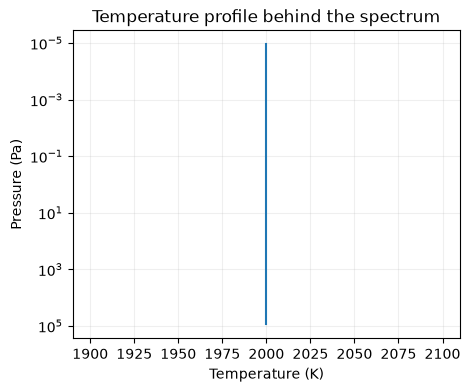

In [5]:
plt.figure(figsize=(5, 4))
plt.plot(em.temperatureProfile, em.pressureProfile)
plt.gca().invert_yaxis()
plt.yscale('log')
plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (Pa)')
plt.title('Temperature profile behind the spectrum')
plt.grid(alpha=0.2)